# Homework 7: Confidence Intervals

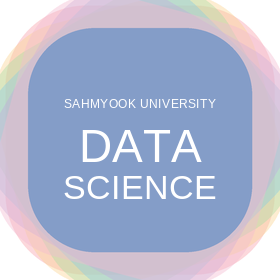

**Helpful Resource:**

- [Python Reference](http://data8.org/sp26/reference/): Cheat sheet of helpful array & table methods used in this data science course!

**Recommended Reading**: 

* [Estimation](https://www.inferentialthinking.com/chapters/13/Estimation)

In [ ]:
# Setup (run this first!)
!pip install -q otter-grader datascience
!git clone https://github.com/jihyungkim94/datascience.git 2>/dev/null || true
import os, json
os.chdir('/content/datascience/hw/hw07')
os.makedirs('tests', exist_ok=True)
with open('hw07.ipynb') as _f:
    _nb = json.load(_f)
for _name, _test in _nb['metadata']['otter']['tests'].items():
    with open('tests/' + _name + '.py', 'w') as _f:
        _f.write('OK_FORMAT = True\n\ntest = ' + repr(_test) + '\n')
import otter
grader = otter.Notebook('hw07.ipynb')
print('Ready! (11 tests loaded)')

Please complete this notebook by filling in the cells provided. **Before you begin, execute the cell below to setup the notebook by importing some helpful libraries.** Each time you start your server, you will need to execute this cell again.

For all problems that you must write explanations and sentences for, you **must** provide your answer in the designated space. Moreover, throughout this homework and all future ones, **please be sure to not re-assign variables throughout the notebook!** For example, if you use `max_temperature` in your answer to one question, do not reassign it later on. Otherwise, you will fail tests that you thought you were passing previously!

Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged.

You should start early so that you have time to get help if you're stuck.

---

The point breakdown for this assignment is given in the table below:
| Category | Points |
| --- | --- |
| Autograder (Coding questions) | 92 |
| Written (Visualization questions) | 8 |
| **Total** | 100 |

In [ ]:
# Don't change this cell; just run it. 

import numpy as np
from datascience import *

# These lines do some fancy plotting magic.",
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt 
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 1. Thai Restaurants in Berkeley

Andrew and Marissa are trying to see what the best Thai restaurant in Berkeley is. They survey 1,500 UC Berkeley students selected uniformly at random and ask each student which Thai restaurant is the best. (*Note: This data is fabricated for the purposes of this homework.*) The choices of Thai restaurants are [Lucky House](https://www.google.com/maps/place/Lucky+House+Thai+Cuisine/@37.8707428,-122.270045,15.32z/data=!4m5!3m4!1s0x80857e9e69a8c921:0x7b6d80f58406fb26!8m2!3d37.8721393!4d-122.2672699), [Imm Thai](https://www.google.com/maps/place/Imm+Thai+Street+Food/@37.8704926,-122.2687372,15.51z/data=!4m5!3m4!1s0x80857e9eec4f1e63:0x5f54d96f0dccdb72!8m2!3d37.8719079!4d-122.2691186), [Thai Temple](https://www.google.com/maps/place/Wat+Mongkolratanaram/@37.8689514,-122.2698649,14.75z/data=!4m5!3m4!1s0x80857e886e39daf1:0xe309caa1b5710fc0!8m2!3d37.8563633!4d-122.2707584), and [Thai Basil](https://www.google.com/maps/place/Thai+Basil/@37.8691911,-122.266539,15.37z/data=!4m5!3m4!1s0x80857c2f6ae0e2f1:0x6978b6e8a72d58d4!8m2!3d37.868327!4d-122.258081). After compiling the results, Andrew and Marissa release the following percentages of votes that each restaurant received, from their sample:

|Thai Restaurant  | Percentage|
|:------------:|:------------:|
|Lucky House | 8% |
|Imm Thai | 53% |
|Thai Temple | 25% |
|Thai Basil | 14% |

These percentages represent a uniform random sample of the population of UC Berkeley students. We will attempt to estimate the corresponding *parameters*, or the percentage of the votes that each restaurant will receive from the population (i.e. all UC Berkeley students). We will use confidence intervals to compute a range of values that reflects the uncertainty of our estimates.

The table `votes` contains the results of Andrew and Marissa's survey.

In [ ]:
# Just run this cell
votes = Table.read_table('votes.csv')
votes

---

**Question 1.1.** Complete the function `one_resampled_percentage` below. It should return Imm Thai's ***percentage*** of votes after taking the original table (`tbl`) and performing one bootstrap sample of it. Remember that a percentage is between 0 and 100. **(8 Points)**

*Note 1:* `tbl` will always be in the same format as `votes`.

*Note 2:* This function should be completed **without** `.group` or `.pivot`. Using these functions will cause your code to timeout.

*Hint:* Given a table of votes, how can you figure out what percentage of the votes are for a certain restaurant? **Be sure to use percentages, not proportions, for this question!**


In [ ]:
def one_resampled_percentage(tbl):
    ...

one_resampled_percentage(votes)

In [ ]:
grader.check("q1_1")

---

**Question 1.2.** Complete the `percentages_in_resamples` function such that it simulates and returns an array of **2025 elements**, where each element represents a bootstrapped estimate of the percentage of voters who will vote for Imm Thai. You should use the `one_resampled_percentage` function you wrote above. **(8 Points)**

_Note:_ We perform our simulation with **only 2025 trials** in this problem to reduce the runtime, but we should generally use more repetitions.


In [ ]:
def percentages_in_resamples():
    percentage_imm = make_array()
    ...

In [ ]:
grader.check("q1_2")

In the following cell, we run the function you just defined, `percentages_in_resamples`, and create a histogram of the calculated statistic for the 2025 bootstrap estimates of the percentage of voters who voted for Imm Thai. 

*Note:* This might take a few seconds to run.

In [ ]:
resampled_percentages = percentages_in_resamples()
Table().with_column('Estimated Percentage', resampled_percentages).hist("Estimated Percentage")

---

**Question 1.3.** Using the array `resampled_percentages`, find the values at the two ends of the middle 95% of the bootstrapped percentage estimates. Assign the lower and upper ends of the interval to `imm_lower_bound` and `imm_upper_bound` respectively. **(8 Points)**

*Hint:* If you are stuck on this question, try looking over [Chapter 13.1](https://inferentialthinking.com/chapters/13/1/Percentiles.html) of the textbook, and check out the `percentile` function on the [python reference sheet](https://www.data8.org/sp26/reference/).


In [ ]:
imm_lower_bound = ...
imm_upper_bound = ...
print(f"Bootstrapped 95% confidence interval for the percentage of Imm Thai voters in the population: [{imm_lower_bound:.2f}, {imm_upper_bound:.2f}]")

In [ ]:
grader.check("q1_3")

---

**Question 1.4.** The survey results seem to indicate that Imm Thai is beating all the other Thai restaurants among the voters. We would like to use confidence intervals to determine a range of likely values for Imm Thai's percentage lead over all the other restaurants combined. The calculation for Imm Thai's lead over Lucky House, Thai Temple, and Thai Basil combined is:

$$\text{Imm Thai's \% of Vote} - (\text{100\%} - \text{Imm Thai's \% of Vote})$$

Define the function `one_resampled_difference` that returns **exactly one value** of Imm Thai's percentage lead over Lucky House, Thai Temple, and Thai Basil combined from one bootstrap sample of `tbl`. **(8 Points)**

*Hint 1:* Imm Thai's lead can be negative.

*Hint 2:* Given a table of votes, how can you figure out what percentage of the votes are for a certain restaurant? **Be sure to use percentages, not proportions, for this question!**

*Note:* If the skeleton code provided within the function is not helpful for you, feel free to approach the question using your own variables.


In [ ]:
def one_resampled_difference(tbl):
    bootstrap = ...
    imm_percentage = ...
    ...

In [ ]:
grader.check("q1_4")

<!-- BEGIN QUESTION -->

---

**Question 1.5.** Write a function called `leads_in_resamples` that computes 2025 bootstrapped elements of Imm Thai's percentage lead over Lucky House, Thai Temple, and Thai Basil combined (the result of calling `one_resampled_difference`). It should return an array of the 2025 bootstrapped estimates. Afterwards, run the cell to plot a histogram of the resulting samples. **(8 Points)**

*Hint:* If you see an error involving `NoneType`, consider what components a function needs to have!


In [ ]:
def leads_in_resamples():
    ...

sampled_leads = leads_in_resamples()
Table().with_column('Estimated Lead', sampled_leads).hist("Estimated Lead")

<!-- END QUESTION -->

---

**Question 1.6.** Use the simulated data in `sampled_leads` from Question 1.5 to compute an approximate 95% confidence interval for Imm Thai's percentage lead over Lucky House, Thai Temple, and Thai Basil combined. **(10 Points)**


In [ ]:
diff_lower_bound = ...
diff_upper_bound = ...
print("Bootstrapped 95% confidence interval for Imm Thai's true lead over Lucky House, Thai Temple, and Thai Basil combined: [{:f}%, {:f}%]".format(diff_lower_bound, diff_upper_bound))

In [ ]:
grader.check("q1_6")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

### 2. Interpreting Confidence Intervals 

Tim computed the following 95% confidence interval for the percentage of Imm Thai voters: 

$$[50.53, 55.53]$$

(Your answer from 1.3 may have been a bit different due to randomness; that doesn't mean it was wrong!)

---

**Question 2.1.** Tim also created 70%, 90%, and 99% confidence intervals from the same sample, but he forgot to label which confidence interval represented which percentages! ***First***, **match each confidence level (70%, 90%, 99%) with one of the corresponding intervals given** (e.g. `CI_70_percent = 1`). **(5 points)**

The intervals are below:

1. [50.03, 55.94]
2. [52.1, 54]
3. [50.97, 54.99]

*Hint:* If you are stuck on this question, try looking over Chapters [13.3](https://inferentialthinking.com/chapters/13/3/Confidence_Intervals.html) and [13.4](https://inferentialthinking.com/chapters/13/4/Using_Confidence_Intervals.html) of the textbook.


In [ ]:
CI_70_percent = ...
CI_90_percent = ...
CI_99_percent = ...

In [ ]:
grader.check("q2_1")

**Question 2.2.** How did you arrive at your answer to Question 2.1? Select all correct answers that correctly interpet confidence levels and assign them to the array `confidence_answers`. (e.g. `confidence_answers = make_array(1,2,3)`) **(5 Points)**

1. Higher confidence levels lead to **wider** intervals because we include **more** of the statistics.

2. As confidence increases, we become **more** confident that the population parameter lies within our confidence interval.

3. Higher confidence levels lead to **smaller** intervals because we include **less** of the statistics.

4. As confidence increases, we become **less** confident that the population parameter lies within our confidence interval.

In [ ]:
confidence_answers = make_array(...)

In [ ]:
grader.check("q2_2")

---

**Question 2.3.** Suppose we produced **6,000 new samples** (each one a new/distinct uniform random sample of 1,500 students) from the population and **created a 95% confidence interval from each one**. **Roughly how many of those 6,000 intervals do you expect will actually contain the true percentage of the population?** **(10 Points)**

Assign your answer to `true_percentage_intervals`.


In [ ]:
true_percentage_intervals = ...

In [ ]:
grader.check("q2_3")

Recall the second bootstrap confidence interval you created, which estimated Imm Thai's lead over Lucky House, Thai Temple, and Thai Basil combined. Among
voters in the sample, Imm Thai's lead was 6%. Tim's 95% confidence interval for the true lead (in the population of all voters) was:

$$[1.2, 11.2]$$

Suppose we are interested in testing a simple yes-or-no question:

> "Is the percentage of votes for Imm Thai equal to the percentage of votes for Lucky House, Thai Temple, and Thai Basil combined?"

Our null hypothesis is that the percentages are equal, or equivalently, that Imm Thai's lead is exactly 0. Our alternative hypothesis is that Imm Thai's lead is not equal to 0.  In the questions below, don't compute any confidence interval yourself—use only Tim's 95% confidence interval.

> Hint: Try thinking about the width of the 95% confidence interval in comparison to the new confidence intervals in the questions below. **Drawing a picture may help.**

---

**Question 2.4.** Say we use a 5% p-value cutoff. Do we reject the null, fail to reject the null, or are we unable to tell using Tim's confidence interval? **(10 Points)**

Assign `cutoff_five_percent` to the number corresponding to the correct answer.

1. Reject the null / Data is consistent with the alternative hypothesis
2. Fail to reject the null / Data is consistent with the null hypothesis
3. Unable to tell using Tim's confidence interval

*Hint:* Consider the relationship between the p-value cutoff and confidence. If you're confused, take a look at [this chapter](https://inferentialthinking.com/chapters/13/4/Using_Confidence_Intervals.html) of the textbook.


In [ ]:
cutoff_five_percent = ...

In [ ]:
grader.check("q2_4")

---

**Question 2.5.** What if, instead, we use a p-value cutoff of 1%? Do we reject the null, fail to reject the null, or are we unable to tell using Tim's confidence interval? **(10 Points)**

Assign `cutoff_one_percent` to the number corresponding to the correct answer.

1. Reject the null / Data is consistent with the alternative hypothesis
2. Fail to reject the null / Data is consistent with the null hypothesis
3. Unable to tell using Tim's confidence interval


In [ ]:
cutoff_one_percent = ...

In [ ]:
grader.check("q2_5")

---

**Question 2.6.** What if we use a p-value cutoff of 10%? Do we reject, fail to reject, or are we unable to tell using our confidence interval? **(10 Points)**

Assign `cutoff_ten_percent` to the number corresponding to the correct answer.

1. Reject the null / Data is consistent with the alternative hypothesis
2. Fail to reject the null / Data is consistent with the null hypothesis
3. Unable to tell using Tim's confidence interval


In [ ]:
cutoff_ten_percent = ...

In [ ]:
grader.check("q2_6")

You're done with Homework 7!  

**Important submission steps:**
1. Run all the cells and verify that every test passes.
2. Choose **File → Download → Download .ipynb**.
3. Upload the `.ipynb` file to the LMS.

**Make sure every cell has been run before you download — the outputs are part of what you hand in.**


### Pets of this data science course

Iggi is proud of you for completing the assignment!

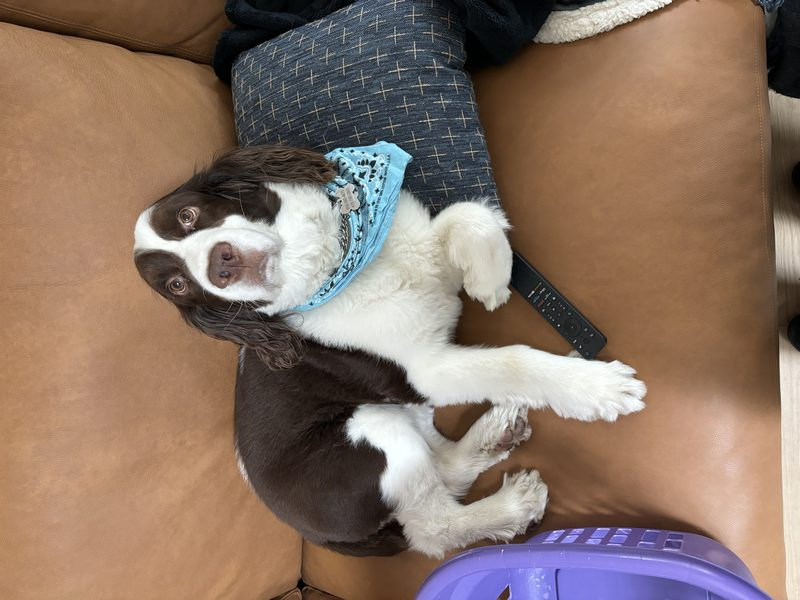

Congrats on finishing Homework 7!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [ ]:
grader.check_all()

### Submission
1. Run `grader.check_all()` above and make sure all tests pass.
2. **File → Download → Download .ipynb**
3. Upload the `.ipynb` file to the LMS.

_(`grader.export()` does not work on Google Colab, so it has been removed.)_